# Análise Completa do Campeonato Brasileiro
Notebook com análises estatísticas, gráficos e correlações.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dados = pd.read_csv('train.csv', sep=';', encoding='latin1')

print(dados.head())

    Ano          Clube  Posicao  Investimento_Milhoes  Gols_Feitos  \
0  2014       Flamengo        1                   182           63   
1  2014      Palmeiras        2                   268           55   
2  2014      São Paulo        3                   294           45   
3  2014    Corinthians        4                   179           74   
4  2014  Internacional        5                   229           36   

   Gols_Sofridos  Saldo_Gols  Pontos  
0             34          29      52  
1             58          -3      63  
2             30          15      68  
3             43          31      47  
4             43          -7      74  


## Estrutura da Base

In [2]:
print(dados.info())

print(dados.describe())

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Ano                   100 non-null    int64
 1   Clube                 100 non-null    str  
 2   Posicao               100 non-null    int64
 3   Investimento_Milhoes  100 non-null    int64
 4   Gols_Feitos           100 non-null    int64
 5   Gols_Sofridos         100 non-null    int64
 6   Saldo_Gols            100 non-null    int64
 7   Pontos                100 non-null    int64
dtypes: int64(7), str(1)
memory usage: 6.4 KB
None
               Ano     Posicao  Investimento_Milhoes  Gols_Feitos  \
count   100.000000  100.000000            100.000000   100.000000   
mean   2018.500000    5.500000            261.650000    58.270000   
std       2.886751    2.886751             89.519974    13.450136   
min    2014.000000    1.000000             88.000000    35.000000   
25%    2016.000000    

## Quantidade de clubes únicos

In [3]:
print('Quantidade de clubes:', dados['Clube'].nunique())

print(dados['Clube'].unique())

Quantidade de clubes: 10
<StringArray>
[     'Flamengo',     'Palmeiras',     'São Paulo',   'Corinthians',
 'Internacional',        'Grêmio',   'Atlético-MG',        'Santos',
    'Fluminense',      'Botafogo']
Length: 10, dtype: str


## Clubes campeões

In [4]:
campeoes = dados[dados['Posicao'] == 1]
print(campeoes[['Ano', 'Clube', 'Pontos']])

     Ano     Clube  Pontos
0   2014  Flamengo      52
10  2015  Flamengo      70
20  2016  Flamengo      59
30  2017  Flamengo      70
40  2018  Flamengo      50
50  2019  Flamengo      55
60  2020  Flamengo      63
70  2021  Flamengo      52
80  2022  Flamengo      67
90  2023  Flamengo      77


## Clubes com mais títulos

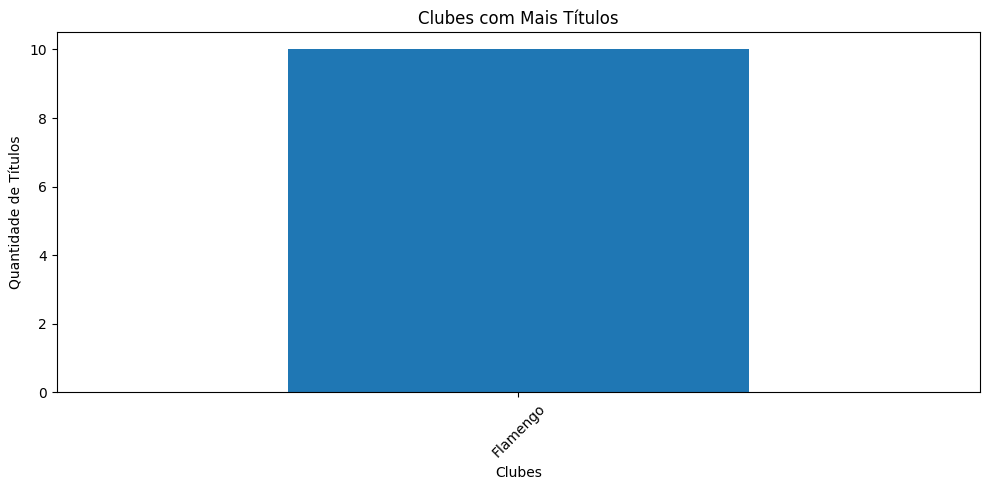

In [5]:
titulos = campeoes['Clube'].value_counts()

plt.figure(figsize=(10,5))
titulos.plot(kind='bar')
plt.title('Clubes com Mais Títulos')
plt.xlabel('Clubes')
plt.ylabel('Quantidade de Títulos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Média de pontos por clube

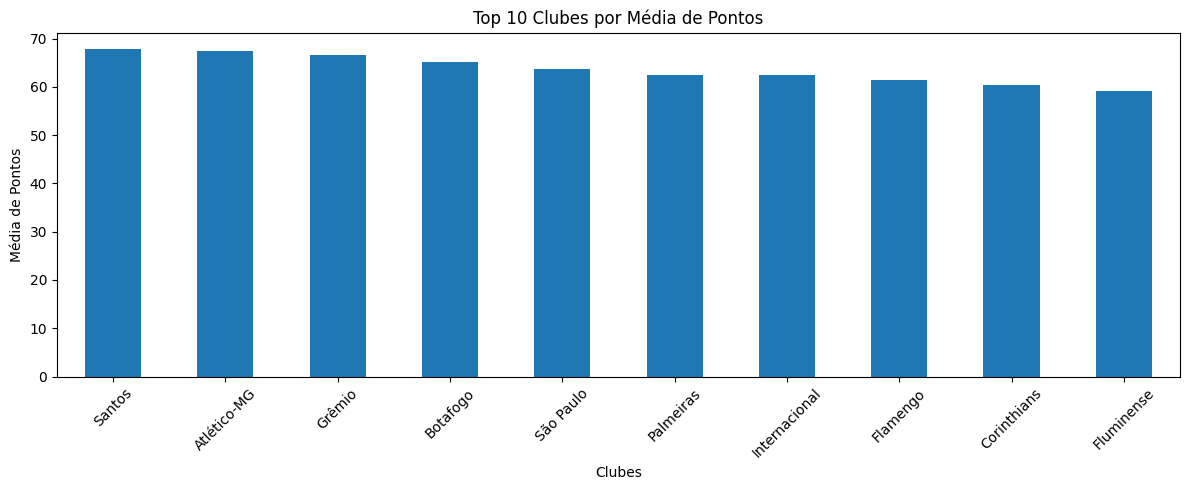

In [6]:
media_pontos = dados.groupby('Clube')['Pontos'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
media_pontos.head(10).plot(kind='bar')
plt.title('Top 10 Clubes por Média de Pontos')
plt.xlabel('Clubes')
plt.ylabel('Média de Pontos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Relação entre investimento e pontos

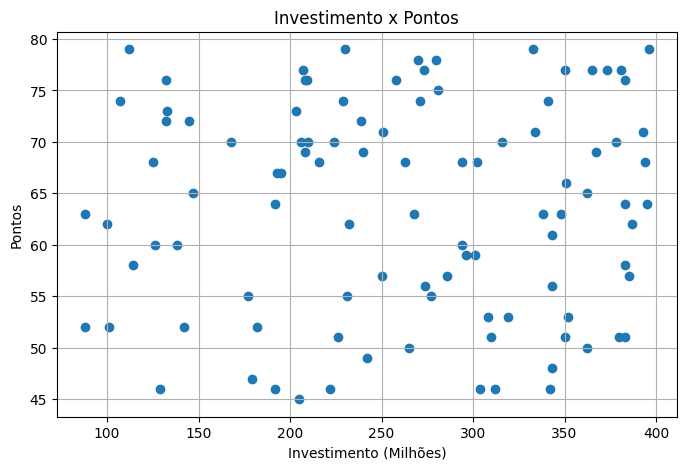

In [7]:
plt.figure(figsize=(8,5))
plt.scatter(dados['Investimento_Milhoes'], dados['Pontos'])
plt.title('Investimento x Pontos')
plt.xlabel('Investimento (Milhões)')
plt.ylabel('Pontos')
plt.grid(True)
plt.show()

## Correlação entre variáveis numéricas

In [8]:
correlacao = dados.corr(numeric_only=True)

print(correlacao)

                               Ano       Posicao  Investimento_Milhoes  \
Ano                   1.000000e+00  4.801546e-15              0.208042   
Posicao               4.801546e-15  1.000000e+00              0.000254   
Investimento_Milhoes  2.080421e-01  2.540673e-04              1.000000   
Gols_Feitos           8.467978e-02 -5.840434e-02             -0.009853   
Gols_Sofridos         2.083411e-01  1.172212e-02             -0.042247   
Saldo_Gols           -6.691905e-02 -5.141581e-02              0.019090   
Pontos               -5.118271e-04  9.195827e-02              0.016249   

                      Gols_Feitos  Gols_Sofridos  Saldo_Gols    Pontos  
Ano                      0.084680       0.208341   -0.066919 -0.000512  
Posicao                 -0.058404       0.011722   -0.051416  0.091958  
Investimento_Milhoes    -0.009853      -0.042247    0.019090  0.016249  
Gols_Feitos              1.000000      -0.038897    0.778758 -0.056065  
Gols_Sofridos           -0.038897       1.

## Evolução dos gols ao longo dos anos

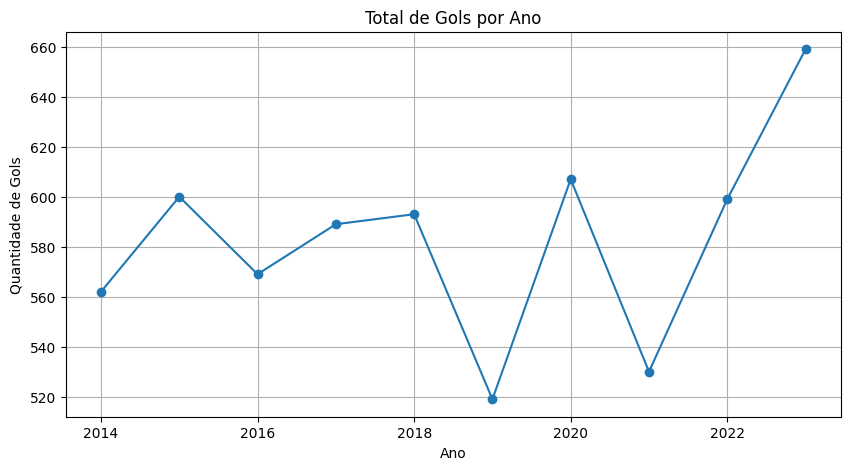

In [9]:
gols_ano = dados.groupby('Ano')['Gols_Feitos'].sum()

plt.figure(figsize=(10,5))
gols_ano.plot(marker='o')
plt.title('Total de Gols por Ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade de Gols')
plt.grid(True)
plt.show()

## Clubes com melhor saldo de gols

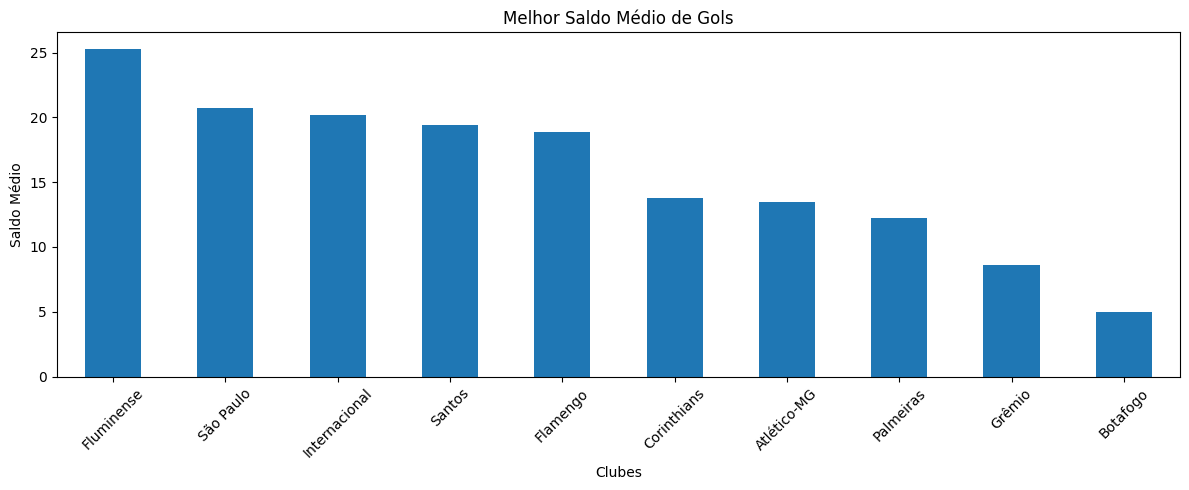

In [10]:
saldo = dados.groupby('Clube')['Saldo_Gols'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
saldo.head(10).plot(kind='bar')
plt.title('Melhor Saldo Médio de Gols')
plt.xlabel('Clubes')
plt.ylabel('Saldo Médio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Distribuição de pontos

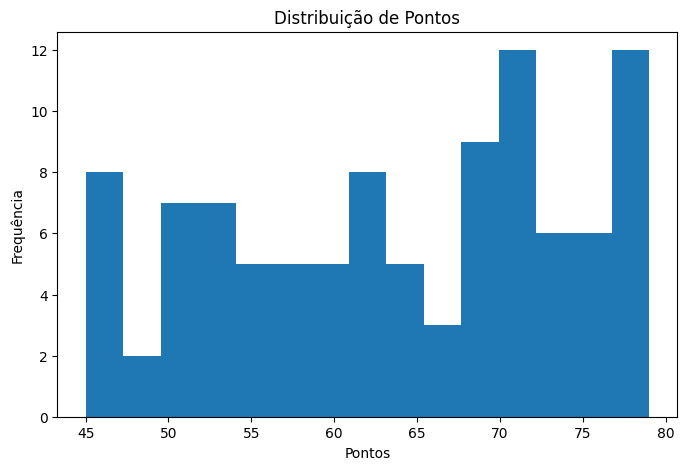

In [11]:
plt.figure(figsize=(8,5))
plt.hist(dados['Pontos'], bins=15)
plt.title('Distribuição de Pontos')
plt.xlabel('Pontos')
plt.ylabel('Frequência')
plt.show()

- Os clubes com maior investimento tendem a conquistar mais pontos.
- Existe relação entre saldo de gols e posição final no campeonato.
- Alguns clubes apresentam consistência histórica em vitórias e títulos.
- O número de gols varia ao longo das temporadas.